# Unidade IV — Mineração de Padrões

## Algoritmo Apriori

**Carga estimada:** 3 horas  
**Pré-requisitos:** itemsets, suporte, combinações e Python.

> **Pergunta norteadora:** como evitar testar todas as combinações quando o espaço de busca cresce exponencialmente?


## Objetivos de aprendizagem

Ao concluir este notebook, você será capaz de:

- explicar a propriedade antimonótona do suporte;
- descrever geração, poda e contagem de candidatos;
- acompanhar visualmente a passagem de candidatos $C_k$ para frequentes $L_k$;
- implementar uma versão didática do Apriori;
- analisar como suporte mínimo altera custo e resultados.


In [1]:
from itertools import combinations
from math import ceil

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from mlxtend.frequent_patterns import apriori
from mlxtend.preprocessing import TransactionEncoder

sns.set_theme(style="whitegrid", context="notebook")


In [2]:
transacoes = [
    {"arroz", "feijao", "oleo"}, {"arroz", "feijao"},
    {"arroz", "leite"}, {"pao", "leite", "manteiga"},
    {"pao", "leite"}, {"arroz", "feijao", "oleo"},
    {"pao", "cafe"}, {"arroz", "feijao", "leite"},
    {"pao", "leite", "manteiga"}, {"arroz", "feijao"},
    {"cafe", "leite"}, {"arroz", "feijao", "oleo", "leite"},
]
itens = sorted(set().union(*transacoes))
pd.Series({"transacoes": len(transacoes), "itens_distintos": len(itens), "combinacoes_nao_vazias": 2 ** len(itens) - 1})


transacoes                 12
itens_distintos             7
combinacoes_nao_vazias    127
dtype: int64

## Propriedade antimonótona

Se $X\subseteq Y$, toda transação que contém $Y$ também contém $X$. Portanto,

$$\operatorname{sup}(Y)\leq\operatorname{sup}(X).$$

Se um itemset é infrequente, nenhum de seus supersets pode ser frequente no mesmo limiar. A implicação inversa não vale: subconjuntos frequentes são necessários, mas não garantem que sua união seja frequente.


## Geração e poda

1. Conte itemsets de tamanho 1 e mantenha os frequentes.
2. Una frequentes para gerar candidatos de tamanho $k$.
3. Pode um candidato se algum subconjunto de tamanho $k-1$ for infrequente.
4. Conte os candidatos restantes e repita até não haver novos frequentes.

A implementação abaixo privilegia transparência, não desempenho industrial.


In [3]:
def suporte(itemset: frozenset[str], compras: list[set[str]]) -> float:
    return sum(itemset.issubset(compra) for compra in compras) / len(compras)


def apriori_didatico(
    compras: list[set[str]], min_support: float
) -> tuple[pd.DataFrame, pd.DataFrame]:
    universo = sorted(set().union(*compras))
    nivel = {frozenset([item]) for item in universo}
    frequentes: dict[frozenset[str], float] = {}
    auditoria = []
    k = 1

    while nivel:
        avaliados = {c: suporte(c, compras) for c in nivel}
        nivel_frequente = {c for c, s in avaliados.items() if s >= min_support}
        frequentes.update({c: avaliados[c] for c in nivel_frequente})
        auditoria.append({
            "tamanho": k, "candidatos_avaliados": len(nivel),
            "itemsets_frequentes": len(nivel_frequente),
        })
        k += 1
        candidatos = {
            a | b for a in nivel_frequente for b in nivel_frequente
            if len(a | b) == k
        }
        nivel = {
            candidato for candidato in candidatos
            if all(
                frozenset(subconjunto) in nivel_frequente
                for subconjunto in combinations(candidato, k - 1)
            )
        }

    tabela = pd.DataFrame([
        {"support": s, "itemsets": itemset, "tamanho": len(itemset)}
        for itemset, s in frequentes.items()
    ]).sort_values(["tamanho", "support"], ascending=[True, False])
    return tabela.reset_index(drop=True), pd.DataFrame(auditoria)


In [4]:
frequentes_didaticos, auditoria = apriori_didatico(transacoes, min_support=0.25)
display(auditoria)
frequentes_didaticos


,tamanho,candidatos_avaliados,itemsets_frequentes
0,1,7,5
1,2,10,5
2,3,1,1


,support,itemsets,tamanho
0,0.583333,(arroz),1
1,0.583333,(leite),1
2,0.500000,(feijao),1
3,0.333333,(pao),1
4,0.250000,(oleo),1
5,0.500000,"(feijao, arroz)",2
6,0.250000,"(leite, arroz)",2
7,0.250000,"(oleo, arroz)",2
8,0.250000,"(feijao, oleo)",2
9,0.250000,"(pao, leite)",2


## Anatomia visual de uma execução

Vamos abrir a execução anterior. Com 12 transações e suporte mínimo de 25%, um itemset precisa ocorrer em pelo menos

$$\left\lceil 0{,}25\times12\right\rceil=3$$

transações. Em cada nível, $C_k$ representa os candidatos de tamanho $k$ que chegam à contagem, enquanto $L_k$ contém apenas os candidatos cujo suporte alcança o mínimo. Antes de contar $C_3$, o Apriori ainda pode eliminar trios que possuem algum par ausente de $L_2$.

A figura seguinte é autoral e foi gerada com os dados sintéticos deste notebook. As barras mostram contagens absolutas, e os rótulos **ENTRA EM $L_k$** e **FORA DE $L_k$** tornam a decisão independente da cor.


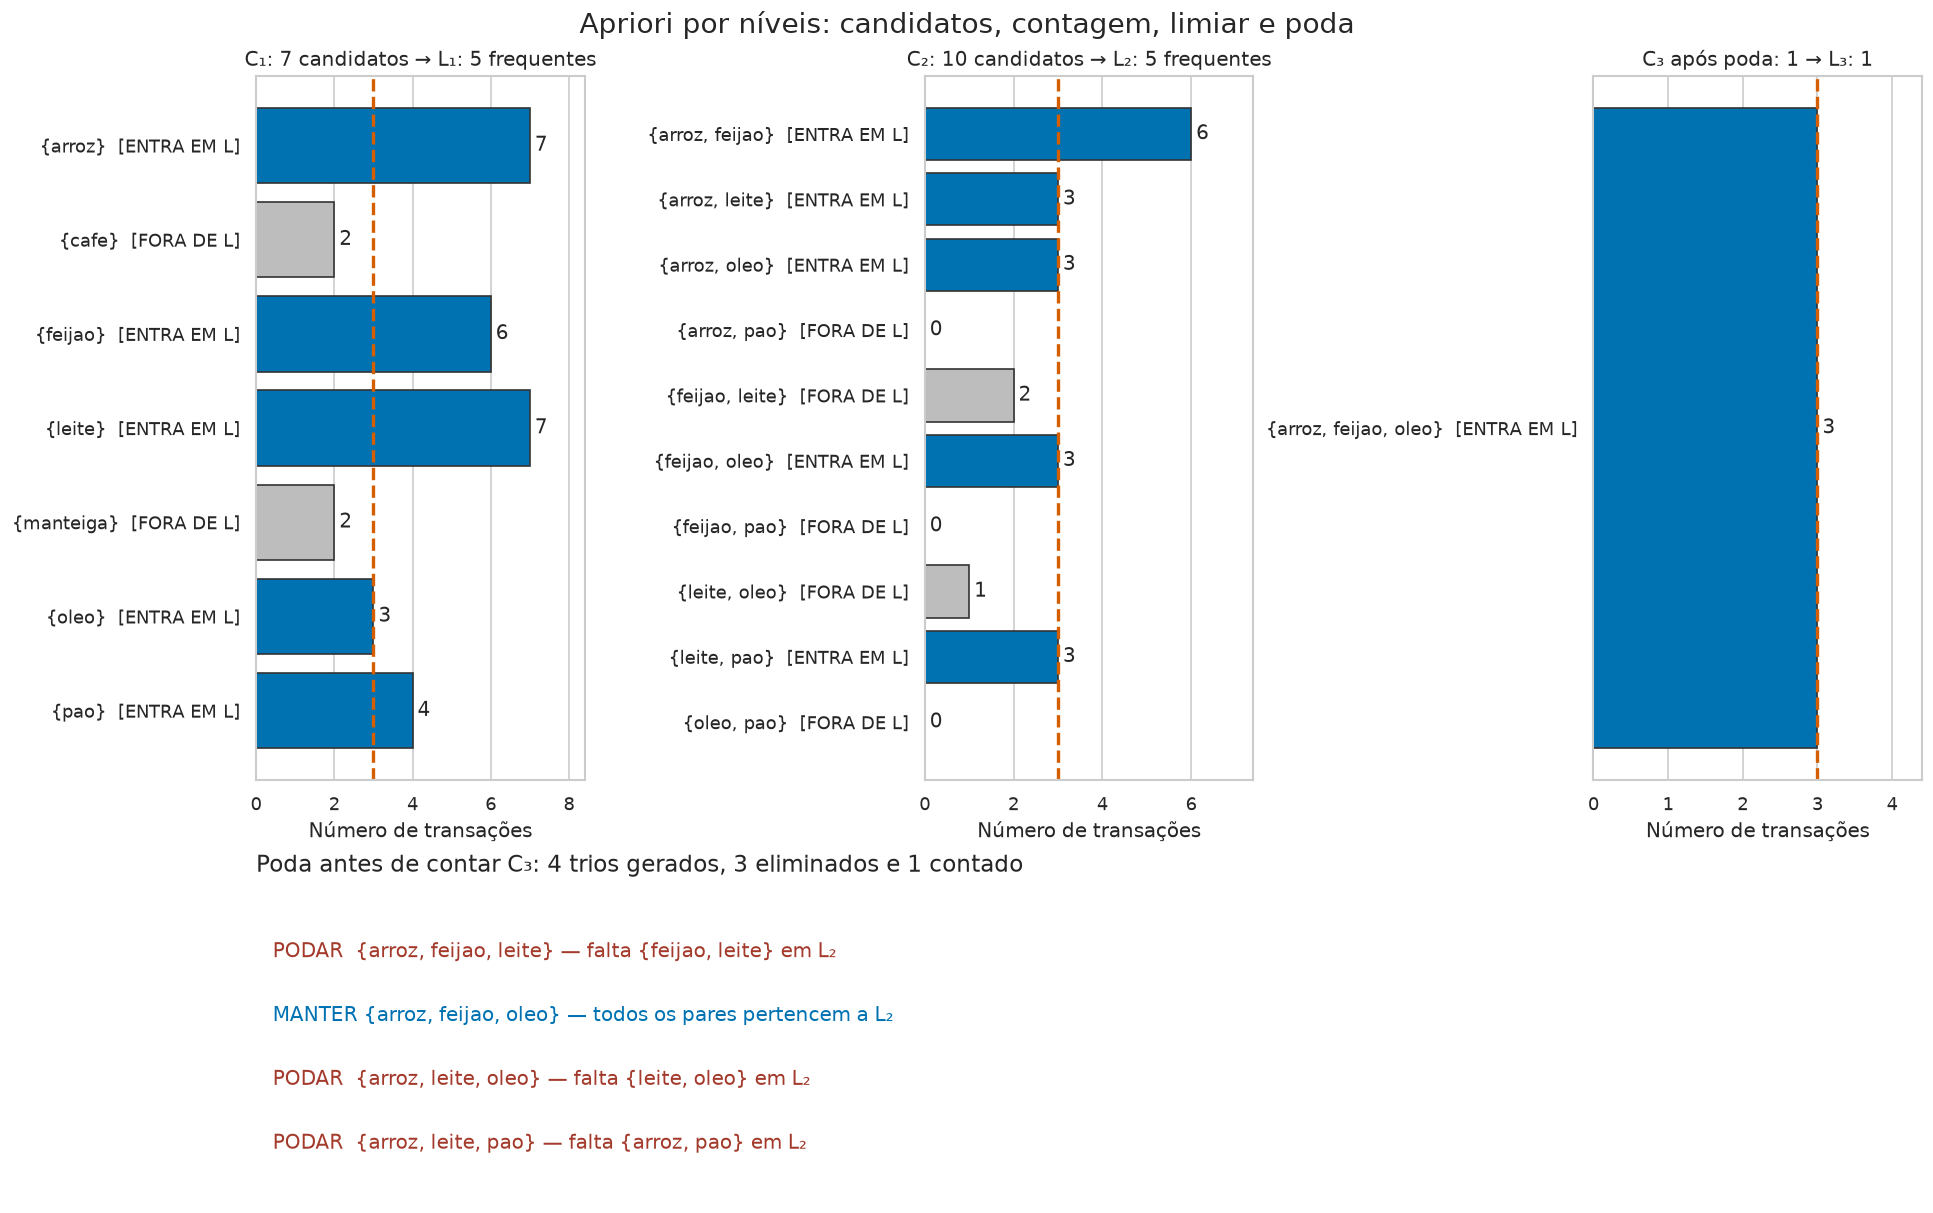

In [5]:
min_support_visual = 0.25
contagem_minima = ceil(min_support_visual * len(transacoes))
chave_itemset = lambda conjunto: tuple(sorted(conjunto))

def contar_ocorrencias(itemset):
    return sum(itemset.issubset(transacao) for transacao in transacoes)

def rotulo_itemset(itemset):
    return "{" + ", ".join(sorted(itemset)) + "}"

c1 = {frozenset([item]) for item in itens}
contagens_c1 = {c: contar_ocorrencias(c) for c in c1}
l1 = {c for c, n in contagens_c1.items() if n >= contagem_minima}

itens_l1 = sorted(next(iter(c)) for c in l1)
c2 = {frozenset(par) for par in combinations(itens_l1, 2)}
contagens_c2 = {c: contar_ocorrencias(c) for c in c2}
l2 = {c for c, n in contagens_c2.items() if n >= contagem_minima}

c3_gerados = {a | b for a in l2 for b in l2 if len(a | b) == 3}
subconjuntos_ausentes = {
    candidato: {
        frozenset(par) for par in combinations(candidato, 2)
        if frozenset(par) not in l2
    }
    for candidato in c3_gerados
}
c3 = {c for c, ausentes in subconjuntos_ausentes.items() if not ausentes}
contagens_c3 = {c: contar_ocorrencias(c) for c in c3}
l3 = {c for c, n in contagens_c3.items() if n >= contagem_minima}

assert contagem_minima == 3
assert (len(c1), len(l1), len(c2), len(l2)) == (7, 5, 10, 5)
assert (len(c3_gerados), len(c3_gerados) - len(c3), len(c3), len(l3)) == (4, 3, 1, 1)

fig, eixos = plt.subplot_mosaic(
    [["c1", "c2", "c3"], ["poda", "poda", "poda"]],
    figsize=(16, 10), dpi=120,
    gridspec_kw={"height_ratios": [3.2, 1.45]},
    layout="constrained",
)

def painel_nivel(ax, candidatos, contagens, frequentes, titulo):
    ordenados = sorted(candidatos, key=chave_itemset)
    valores = [contagens[c] for c in ordenados]
    estados = ["ENTRA EM L" if c in frequentes else "FORA DE L" for c in ordenados]
    rotulos = [f"{rotulo_itemset(c)}  [{estado}]" for c, estado in zip(ordenados, estados)]
    cores = ["#0072B2" if c in frequentes else "#BDBDBD" for c in ordenados]
    barras = ax.barh(rotulos, valores, color=cores, edgecolor="#333333")
    ax.axvline(contagem_minima, color="#D55E00", linestyle="--", linewidth=2)
    ax.bar_label(barras, padding=3)
    ax.invert_yaxis()
    ax.set(title=titulo, xlabel="Número de transações", xlim=(0, max(valores) + 1.4))
    ax.grid(axis="y", visible=False)

painel_nivel(eixos["c1"], c1, contagens_c1, l1, f"C₁: {len(c1)} candidatos → L₁: {len(l1)} frequentes")
painel_nivel(eixos["c2"], c2, contagens_c2, l2, f"C₂: {len(c2)} candidatos → L₂: {len(l2)} frequentes")
painel_nivel(eixos["c3"], c3, contagens_c3, l3, f"C₃ após poda: {len(c3)} → L₃: {len(l3)}")

eixos["poda"].axis("off")
eixos["poda"].set_title(
    f"Poda antes de contar C₃: {len(c3_gerados)} trios gerados, "
    f"{len(c3_gerados) - len(c3)} eliminados e {len(c3)} contado",
    loc="left", fontsize=14,
)
linhas_poda = []
for candidato in sorted(c3_gerados, key=chave_itemset):
    ausentes = subconjuntos_ausentes[candidato]
    if ausentes:
        faltam = ", ".join(rotulo_itemset(s) for s in sorted(ausentes, key=chave_itemset))
        linhas_poda.append(f"PODAR  {rotulo_itemset(candidato)} — falta {faltam} em L₂")
    else:
        linhas_poda.append(f"MANTER {rotulo_itemset(candidato)} — todos os pares pertencem a L₂")

for posicao, texto in enumerate(linhas_poda):
    cor = "#0072B2" if texto.startswith("MANTER") else "#A33A2B"
    eixos["poda"].text(0.01, 0.78 - 0.2 * posicao, texto, transform=eixos["poda"].transAxes,
                       fontsize=12, color=cor, va="center")

fig.suptitle(
    "Apriori por níveis: candidatos, contagem, limiar e poda",
    fontsize=17,
)
plt.show()


A leitura completa da figura é:

1. **Nível 1:** $C_1$ contém os sete itens distintos. Depois da primeira varredura, cinco atingem três ocorrências e formam $L_1$; **café** e **manteiga** ficam de fora.
2. **Nível 2:** somente os cinco itens de $L_1$ participam da geração. As $\binom{5}{2}=10$ combinações formam $C_2$. Após a contagem, cinco pares formam $L_2$.
3. **Geração de trios:** a união dos pares de $L_2$ produz quatro trios possíveis. Três são podados sem nova contagem: $\{arroz, feijao, leite\}$ contém o par infrequente $\{feijao, leite\}$; $\{arroz, leite, oleo\}$ contém $\{leite, oleo\}$; e $\{arroz, leite, pao\}$ contém $\{arroz, pao\}$.
4. **Nível 3:** apenas $\{arroz, feijao, oleo\}$ tem todos os pares em $L_2$, chega a $C_3$, aparece em três transações e entra em $L_3$.
5. **Parada:** não é possível gerar candidato de tamanho 4 a partir de $L_3$, então o algoritmo termina.

A linha tracejada marca a contagem mínima 3. A poda e o filtro por suporte são operações diferentes: a **poda estrutural** usa subconjuntos infrequentes antes de consultar novamente a base; o **filtro de suporte** ocorre depois que os candidatos sobreviventes são contados. Por isso, a auditoria registra 7, 10 e apenas 1 candidato avaliado nos três níveis.


## Comparação com `mlxtend`

Usaremos a mesma matriz e o mesmo limiar. A verificação compara itemsets e suportes, não apenas o número de linhas.


In [6]:
te = TransactionEncoder()
matriz = te.fit([sorted(t) for t in transacoes]).transform(transacoes)
cestas = pd.DataFrame(matriz, columns=te.columns_)
frequentes_biblioteca = apriori(cestas, min_support=0.25, use_colnames=True)
esperado = dict(zip(frequentes_didaticos["itemsets"], frequentes_didaticos["support"]))
obtido = dict(zip(frequentes_biblioteca["itemsets"], frequentes_biblioteca["support"]))
assert esperado.keys() == obtido.keys()
assert all(abs(esperado[k] - obtido[k]) < 1e-12 for k in esperado)
pd.Series({"itemsets_em_cada_implementacao": len(esperado), "resultados_identicos": True})


itemsets_em_cada_implementacao      11
resultados_identicos              True
dtype: object

## Efeito do suporte mínimo

Reduzir o limiar nunca remove um itemset já frequente, mas pode aumentar rapidamente candidatos, resultados e custo. O gráfico descreve esta base pequena, não o tempo assintótico geral.


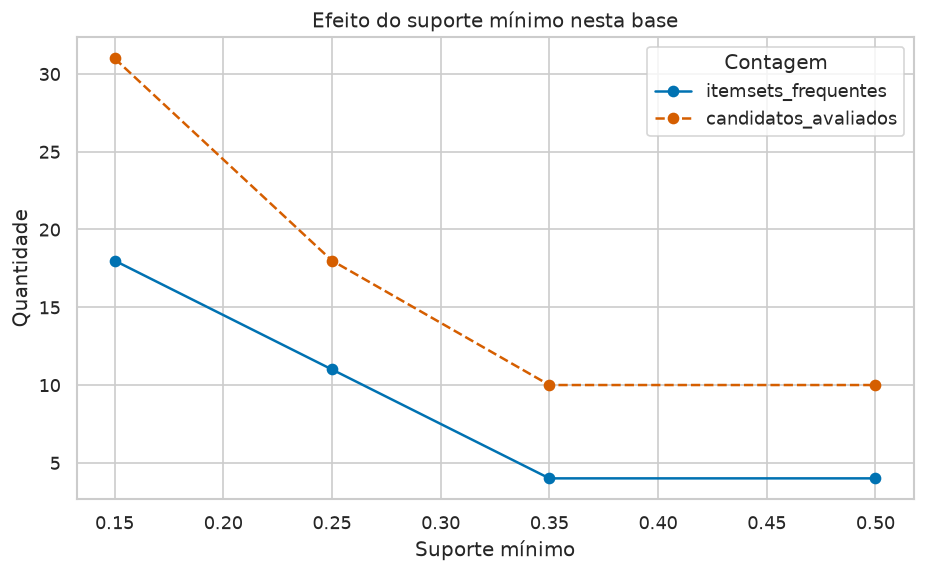

,suporte_minimo,itemsets_frequentes,candidatos_avaliados
0,0.15,18,31
1,0.25,11,18
2,0.35,4,10
3,0.50,4,10


In [7]:
resultados_limiares = []
for limiar in [0.15, 0.25, 0.35, 0.50]:
    frequentes, log = apriori_didatico(transacoes, min_support=limiar)
    resultados_limiares.append({
        "suporte_minimo": limiar, "itemsets_frequentes": len(frequentes),
        "candidatos_avaliados": log["candidatos_avaliados"].sum(),
    })
comparacao = pd.DataFrame(resultados_limiares)
fig, ax = plt.subplots(figsize=(9, 5), dpi=120)
comparacao.plot(
    x="suporte_minimo", y=["itemsets_frequentes", "candidatos_avaliados"],
    marker="o", style=["-", "--"], color=["#0072B2", "#D55E00"], ax=ax,
)
ax.set(title="Efeito do suporte mínimo nesta base", xlabel="Suporte mínimo", ylabel="Quantidade")
ax.legend(title="Contagem")
plt.show()
comparacao


O limiar menor amplia a busca e retorna padrões menos prevalentes. A decisão deve considerar tamanho da base, coincidências, capacidade de revisão e relevância de nichos.

> **U04-NB02-V01 — Verifique seu entendimento:** se `{arroz, cafe}` é infrequente, o que podemos concluir sobre `{arroz, cafe, leite}` e por quê?

> **U04-NB02-E01 — Exercício:** acrescente quatro transações, execute as duas implementações com suportes 0,20 e 0,30 e compare itemsets, candidatos avaliados e interpretação. Explique qualquer mudança causada pelo novo denominador.


## Síntese

- O suporte é antimonótono: supersets não podem ser mais frequentes que subconjuntos.
- Apriori alterna geração, poda e contagem por tamanho.
- Implementações devem ser verificadas pelo conteúdo e pelos valores.
- Limiar menor amplia cobertura e custo, sem garantir utilidade.

## Referências

- HAN, Jiawei; PEI, Jian; TONG, Hanghang. *Data Mining: Concepts and Techniques*. 4. ed. Cambridge: Morgan Kaufmann/Elsevier, 2023. Cap. 4, seção 4.2.
- AGRAWAL, Rakesh; SRIKANT, Ramakrishnan. Fast algorithms for mining association rules. *VLDB*, 1994.
